In [5]:
!pip install librosa soundfile

In [16]:
import zipfile
import os

zip_file_path = '/content/wav.zip'
extraction_path = '/content/wav2'

print(f"Unzipping {zip_file_path} to {extraction_path}...")
with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(extraction_path)
print("Unzipping complete.")

print("\nContents of extracted directory:")
for root, dirs, files in os.walk(extraction_path):
    level = root.replace(extraction_path, '').count(os.sep)
    indent = ' ' * 4 * (level)
    print(f'{indent}{os.path.basename(root)}/')
    subindent = ' ' * 4 * (level + 1)
    for f in files[:5]:
        print(f'{subindent}{f}')
    if len(files) > 5:
        print(f'{subindent}...')
    break

Unzipping /content/wav.zip to /content/wav2...
Unzipping complete.

Contents of extracted directory:
wav2/


In [21]:
import os
import librosa
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import LabelEncoder
import pickle
import warnings
warnings.filterwarnings('ignore')

print("Libraries successfully imported!")

Libraries successfully imported!


In [43]:
import os
import librosa
import pandas as pd
import numpy as np

def perform_audio_eda(dataset_path):
    data_list = []
    print(f"Analyzing dataset at: {dataset_path}...")

    for speaker in os.listdir(dataset_path):
        speaker_path = os.path.join(dataset_path, speaker)
        if os.path.isdir(speaker_path):
            files = [f for f in os.listdir(speaker_path) if f.endswith('.wav')]
            for f in files:
                file_path = os.path.join(speaker_path, f)
                duration = librosa.get_duration(path=file_path)
                data_list.append({
                    'speaker': speaker,
                    'file_name': f,
                    'duration_sec': duration
                })

    df = pd.DataFrame(data_list)

    print("\n--- Dataset Summary ---")
    print(f"Total Speakers: {df['speaker'].nunique()}")
    print(f"Total Audio Files: {len(df)}")
    print(f"Average Duration: {df['duration_sec'].mean():.2f} seconds")
    print(f"Shortest Clip: {df['duration_sec'].min():.2f} seconds")
    print(f"Longest Clip: {df['duration_sec'].max():.2f} seconds")

    print("\n--- Speaker Breakdown ---")
    breakdown = df.groupby('speaker')['duration_sec'].agg(['count', 'mean', 'sum']).rename(columns={'count': 'File Count', 'mean': 'Avg Duration', 'sum': 'Total Duration'})
    print(breakdown)

    return df

eda_df = perform_audio_eda("/content/wav2/wav")

Analyzing dataset at: /content/wav2/wav...

--- Dataset Summary ---
Total Speakers: 4
Total Audio Files: 377
Average Duration: 7.04 seconds
Shortest Clip: 3.96 seconds
Longest Clip: 42.76 seconds

--- Speaker Breakdown ---
               File Count  Avg Duration  Total Duration
speaker                                                
Eartha_Kitt           158      6.612974     1044.849875
Ed_Westwick            73      6.011569      438.844562
Eddie_Griffin          50      6.741663      337.083125
Eddie_Izzard           96      8.672146      832.526000


In [27]:
file_path="/content/wav2/wav"
def extract_features(file_path):
    try:
        audio, sample_rate = librosa.load(file_path, sr=16000)
        mfccs = librosa.feature.mfcc(y=audio, sr=sample_rate, n_mfcc=40)
        mfccs_processed = np.mean(mfccs.T, axis=0)
        return mfccs_processed
    except Exception as e:
        print(f"Error processing {file_path}: {e}")
        return None

print("Feature extraction function ready!")

Feature extraction function ready!


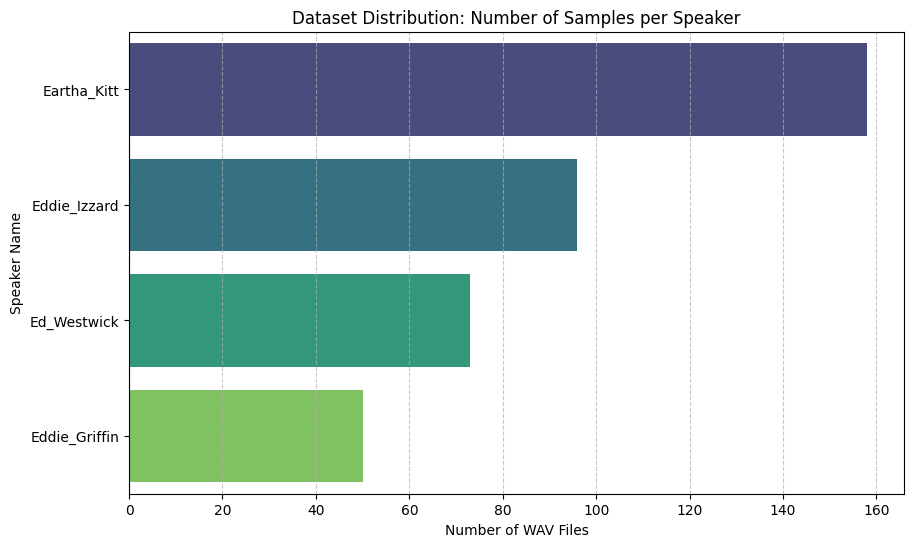

In [40]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

unique, counts = np.unique(y, return_counts=True)
speaker_counts = dict(zip(unique, counts))

df_stats = pd.DataFrame(list(speaker_counts.items()), columns=['Speaker', 'Sample Count'])
df_stats = df_stats.sort_values(by='Sample Count', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Sample Count', y='Speaker', data=df_stats, palette='viridis')
plt.title('Dataset Distribution: Number of Samples per Speaker')
plt.xlabel('Number of WAV Files')
plt.ylabel('Speaker Name')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

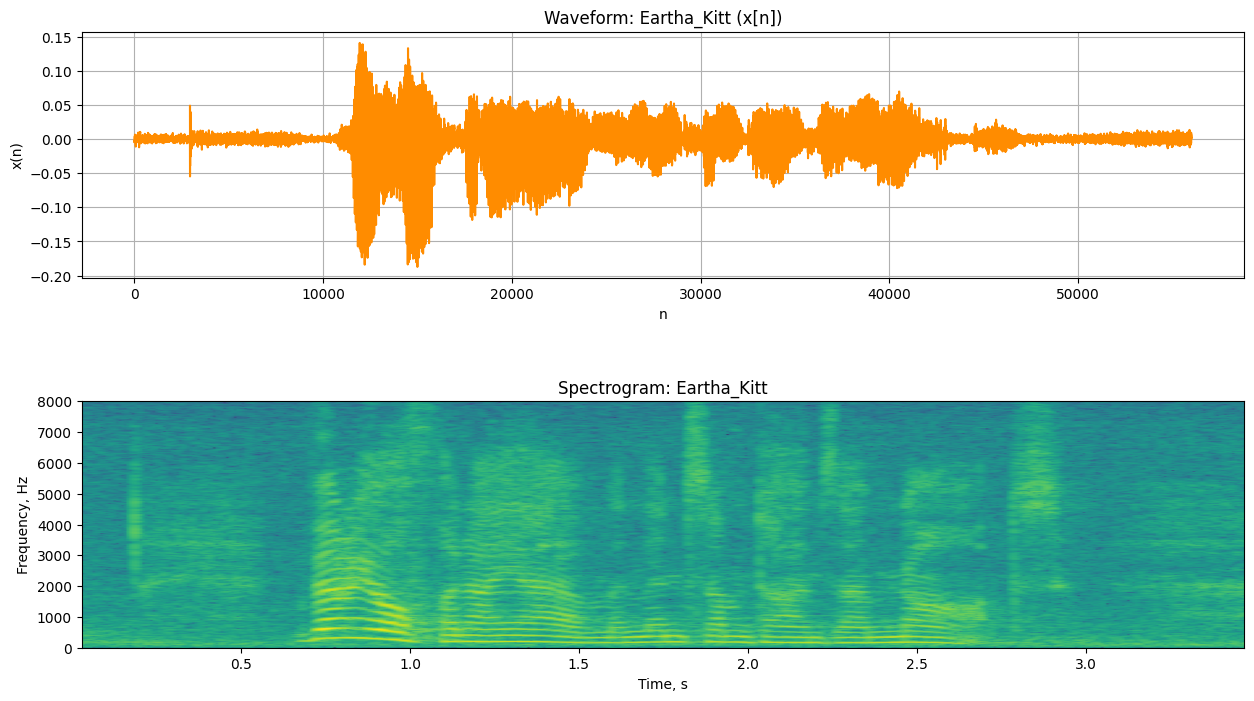

In [42]:
import matplotlib.pyplot as plt
import librosa
import numpy as np

# Load a file from a different speaker: Eartha_Kitt
sample_rate = 16000
test_file = "/content/wav2/wav/Eartha_Kitt/5r0dWxy17C8_00001.wav"
signal, sr = librosa.load(test_file, sr=sample_rate)

# Keep the first 3.5 seconds
signal = signal[0:int(3.5 * sample_rate)]

plt.figure(1, figsize=(15, 8))

# Waveform Plot
plot_a = plt.subplot(211)
plt.subplots_adjust(wspace=0, hspace=0.5)
plot_a.plot(signal, color='darkorange')
plot_a.set_title('Waveform: Eartha_Kitt (x[n])')
plot_a.set_xlabel('n')
plot_a.set_ylabel('x(n)')
plot_a.grid(True)

# Spectrogram Plot
plot_b = plt.subplot(212)
plot_b.specgram(signal, NFFT=1024, Fs=sample_rate, noverlap=900, cmap='viridis')
plot_b.set_title('Spectrogram: Eartha_Kitt')
plot_b.set_xlabel('Time, s')
plot_b.set_ylabel('Frequency, Hz')

plt.show()

In [29]:
def load_data(dataset_path):
    X = []
    y = []

    for person_name in os.listdir(dataset_path):
        person_folder = os.path.join(dataset_path, person_name)

        if not os.path.isdir(person_folder):
            continue

        for file_name in os.listdir(person_folder):
            if file_name.endswith('.wav'):
                file_path = os.path.join(person_folder, file_name)
                features = extract_features(file_path)

                if features is not None:
                    X.append(features)
                    y.append(person_name)

    return np.array(X), np.array(y)

dataset_directory = "/content/wav2/wav"
X, y = load_data(dataset_directory)

print("Dataset loading function ready!")

Dataset loading function ready!


In [30]:
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42)

print("Model training start ho rahi hai...")
model = SVC(kernel='linear', probability=True)
model.fit(X_train, y_train)

predictions = model.predict(X_test)
accuracy = accuracy_score(y_test, predictions)

print(f"\nModel Training Complete! Accuracy: {accuracy * 100:.2f}%")
print("\nClassification Report:\n", classification_report(y_test, predictions, target_names=label_encoder.classes_))

with open('speaker_model.pkl', 'wb') as f:
    pickle.dump(model, f)
with open('label_encoder.pkl', 'wb') as f:
    pickle.dump(label_encoder, f)

Model training start ho rahi hai...
\nModel Training Complete! Accuracy: 97.37%
\nClassification Report:\n                precision    recall  f1-score   support

  Eartha_Kitt       1.00      1.00      1.00        23
  Ed_Westwick       0.88      1.00      0.94        15
Eddie_Griffin       1.00      0.91      0.95        11
 Eddie_Izzard       1.00      0.96      0.98        27

     accuracy                           0.97        76
    macro avg       0.97      0.97      0.97        76
 weighted avg       0.98      0.97      0.97        76



In [46]:
import librosa
import soundfile as sf
import os

def recognize_speaker(audio_path, trained_model, encoder):
    features = extract_features(audio_path)

    if features is not None:
        features = features.reshape(1, -1)
        predicted_id = trained_model.predict(features)[0]
        person_name = encoder.inverse_transform([predicted_id])[0]

        probabilities = trained_model.predict_proba(features)[0]
        confidence = probabilities[predicted_id] * 100

        return person_name, confidence
    else:
        return "Audio process nahi ho saka", 0

test_audio_file = "/content/x6uYqmx31kE_00019.wav"
predicted_name, conf = recognize_speaker(test_audio_file, model, label_encoder)
print(f"Prediction: Ye awaz {predicted_name} ki lag rhi hai (Confidence: {conf:.2f}%)")

Prediction: Ye awaz Eartha_Kitt ki lag rhi hai (Confidence: 93.44%)
